<a href="https://colab.research.google.com/github/alsavira/classification-analysis/blob/main/Classification_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Analisis Klasifikasi Developer Burnout**

---
### **Informasi Mahasiswa**
> **Nama:** Safira Khoirulanisa Salsabila  
> **NIM:** 2304010001  
> **Prodi:** D3 Statistika Terapan dan Komputasi

---

## **1. Latar Belakang**
Di era pengembangan perangkat lunak yang semakin intens, *burnout* di kalangan developer telah menjadi isu serius yang berdampak pada:
* **Produktivitas:** Penurunan performa kerja secara signifikan.
* **Kualitas Kode:** Meningkatnya risiko kesalahan teknis.
* **Kesehatan Mental:** Tekanan psikologis jangka panjang.

Faktor-faktor seperti jadwal yang padat, tekanan *bug* yang menumpuk, hingga minimnya waktu istirahat merupakan pemicu utama yang terus menggerogoti ketahanan kerja seorang developer.

## **2. Metodologi & Tujuan**
Penelitian ini menerapkan pendekatan *machine learning* terhadap **7.000 data observasi developer**. Variabel yang dianalisis meliputi:
* Jam kerja harian & waktu layar (*screen time*).
* Durasi tidur & frekuensi *commit*.
* Jumlah *bug* yang ditangani.
* Level stres yang terukur.

**Tujuan Utama:** Membangun model klasifikasi yang mampu memprediksi tingkat *burnout* ke dalam tiga kategori:
1. 🟢 **Low** (Rendah)
2. 🟡 **Medium** (Sedang)
3. 🔴 **High** (Tinggi)

## **3. Sumber Data**
Data yang digunakan dalam analisis ini bersumber dari Kaggle:  
🔗 [Developer Burnout Prediction Dataset (7.000 Samples)](https://www.kaggle.com/datasets/asifxzaman/developer-burnout-prediction-dataset7000-samples)


# **Import Library**
Memuat seluruh pustaka (*libraries*) di awal notebook guna memastikan manajemen dependensi yang terpusat dan menjaga konsistensi komputasi selama proses analisis.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# **Data**
Memuat dataset developer burnout dari file CSV, dilanjutkan dengan inspeksi awal untuk melihat struktur data sebelum proses pengolahan dimulai

In [ ]:
df_raw = pd.read_csv('/content/drive/MyDrive/Machine Learning/classification/developer_burnout_dataset_7000.csv')

print(f'  Jumlah baris    : {df_raw.shape[0]:,}')
print(f'  Jumlah kolom    : {df_raw.shape[1]}')

  Jumlah baris    : 7,000
  Jumlah kolom    : 12


In [ ]:
display(df_raw.head(), df_raw.tail())

,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
0,26.0,12.0,10.33,4.45,2.0,11.0,4.0,1.0,15.07,0.14,55.96,Medium
1,39.0,10.0,8.62,5.77,5.0,15.0,11.0,5.0,13.25,0.54,82.22,High
2,34.0,13.0,NaN,4.03,5.0,2.0,18.0,9.0,11.18,1.54,61.77,Medium
3,30.0,1.0,6.85,6.47,2.0,15.0,26.0,1.0,11.14,0.96,54.98,Medium
4,27.0,7.0,4.24,5.80,NaN,9.0,17.0,7.0,8.05,0.36,27.90,Low


,age,experience_years,daily_work_hours,sleep_hours,caffeine_intake,bugs_per_day,commits_per_day,meetings_per_day,screen_time,exercise_hours,stress_level,burnout_level
6995,25.0,14.0,6.53,7.43,5.0,1.0,7.0,5.0,7.55,1.67,20.10,Low
6996,30.0,19.0,10.15,5.60,3.0,4.0,9.0,0.0,12.11,0.96,41.71,Medium
6997,44.0,8.0,8.56,6.80,5.0,18.0,3.0,4.0,11.62,1.04,80.15,High
6998,25.0,2.0,4.39,5.40,6.0,6.0,4.0,5.0,8.24,0.82,41.44,Medium
6999,25.0,2.0,4.35,4.83,1.0,16.0,23.0,4.0,8.52,1.98,39.18,Medium


In [ ]:
print(df_raw.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               6860 non-null   float64
 1   experience_years  6860 non-null   float64
 2   daily_work_hours  6860 non-null   float64
 3   sleep_hours       6860 non-null   float64
 4   caffeine_intake   6860 non-null   float64
 5   bugs_per_day      6860 non-null   float64
 6   commits_per_day   6860 non-null   float64
 7   meetings_per_day  6860 non-null   float64
 8   screen_time       6860 non-null   float64
 9   exercise_hours    6860 non-null   float64
 10  stress_level      6860 non-null   float64
 11  burnout_level     6860 non-null   object 
dtypes: float64(11), object(1)
memory usage: 656.4+ KB
None


# **Statistik Deskriptif**
Melakukan analisis eksploratif untuk mengenali pola distribusi variabel sejak dini, sehingga langkah preprocessing dapat dilakukan secara lebih tepat.

In [ ]:
print('\n  [2a] Statistik numerik:')
print(df_raw.describe().round(2))


  [2a] Statistik numerik:
           age  experience_years  daily_work_hours  sleep_hours  caffeine_intake  bugs_per_day  commits_per_day  \
count  6860.00           6860.00           6860.00      6860.00          6860.00       6860.00          6860.00   
mean     32.13              9.58              9.00         6.49             3.54          9.48            14.46   
std       7.23              5.76              2.86         1.45             2.28          5.75             8.67   
min      20.00              0.00              4.00         4.00             0.00          0.00             0.00   
25%      26.00              5.00              6.56         5.22             2.00          5.00             7.00   
50%      32.00             10.00              8.99         6.46             4.00          9.00            14.00   
75%      38.00             15.00             11.42         7.74             6.00         14.00            22.00   
max      44.00             19.00             14.00   

Dataset menunjukkan rentang nilai yang sangat bervariasi antar fitur: `stress_level` berskala 0-100, `bugs_per_day` 0-25, sedangkan `sleep_hours` hanya 2-11 jam. Perbedaan skala yang signifikan ini menjadi alasan kuat untuk menerapkan normalisasi sebelum pemodelan, agar tidak ada fitur yang mendominasi hanya karena besaran nilainya.


In [ ]:
print('\n  [2b] Distribusi burnout_level:')
print(df_raw['burnout_level'].value_counts(dropna=False))


  [2b] Distribusi burnout_level:
burnout_level
Medium    3485
High      1782
Low       1593
NaN        140
Name: count, dtype: int64


Distribusi target `burnout_level` menunjukkan bahwa sebagian besar developer berada pada level **Medium** (49,8%), diikuti **High** (25,5%) dan **Low** (22,8%). Kelas tergolong cukup seimbang sehingga tidak memerlukan teknik oversampling seperti SMOTE. Ditemukan pula 140 baris tanpa label yang akan dihapus pada tahap preprocessing.


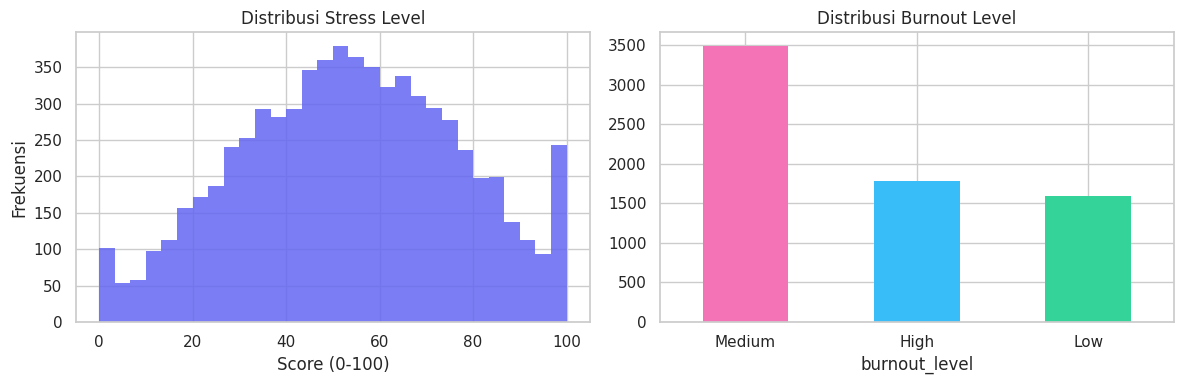

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df_raw['stress_level'].dropna(), bins=30,
             color='#6366f1', edgecolor='none', alpha=0.85)
axes[0].set_title('Distribusi Stress Level')
axes[0].set_xlabel('Score (0-100)')
axes[0].set_ylabel('Frekuensi')

df_raw['burnout_level'].value_counts().plot(
    kind='bar', ax=axes[1],
    color=['#f472b6','#38bdf8','#34d399'], edgecolor='none')
axes[1].set_title('Distribusi Burnout Level')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

Histogram `stress_level` memperlihatkan distribusi yang mendekati normal dengan puncak di rentang 50-60, mengindikasikan bahwa mayoritas developer mengalami tekanan kerja di level menengah. Bar chart `burnout_level` mengonfirmasi dominasi kelas Medium — sebuah pola yang wajar mengingat sebagian besar developer berada dalam kondisi kerja yang intens namun belum mencapai titik kritis burnout.


# **Pre-processing**
Bagian ini merupakan pilar utama dari penelitian ini. Kualitas hasil prediksi dan performa model nantinya akan sangat ditentukan oleh ketelitian dalam melakukan tahap pembersihan dan transformasi data.

In [ ]:
data = pd.read_csv('/content/drive/MyDrive/Machine Learning/classification/developer_burnout_dataset_7000.csv')  # Membaca ulang data mentah
data_copy = data.copy()
print(f'Data mentah berhasil disalin. Shape: {data_copy.shape}')

Data mentah berhasil disalin. Shape: (7000, 12)


## **Cek Imputasi & Missing Values**

In [ ]:
data_copy.isna().sum()

,0
age,140
experience_years,140
daily_work_hours,140
sleep_hours,140
caffeine_intake,140
bugs_per_day,140
commits_per_day,140
meetings_per_day,140
screen_time,140
exercise_hours,140


Dataset ini memiliki **140 nilai kosong** yang tersebar merata (~2%) pada **seluruh kolom sekaligus** dalam baris yang sama. Pola ini mengindikasikan bahwa missing values bukan tersebar acak, melainkan merupakan baris-baris yang sepenuhnya kosong. Strategi penanganan:
- **Kolom target** (`burnout_level`) kosong -> baris **dihapus** karena tidak memiliki label
- **Kolom numerik** -> diisi dengan **median** (lebih robust terhadap outlier dibanding mean)


In [ ]:
miss  = data_copy.isnull().sum()
pct   = (miss / len(data_copy) * 100).round(2)
print('Missing values per kolom:')
print(pd.DataFrame({'Count': miss, 'Persen (%)': pct}))

Missing values per kolom:
                  Count  Persen (%)
age                 140         2.0
experience_years    140         2.0
daily_work_hours    140         2.0
sleep_hours         140         2.0
caffeine_intake     140         2.0
bugs_per_day        140         2.0
commits_per_day     140         2.0
meetings_per_day    140         2.0
screen_time         140         2.0
exercise_hours      140         2.0
stress_level        140         2.0
burnout_level       140         2.0


Hasil identifikasi menunjukkan **140 baris** kosong secara konsisten di semua kolom (2%). Karena `burnout_level` juga ikut kosong di baris yang sama, baris-baris tersebut tidak memiliki nilai target dan harus dihapus terlebih dahulu sebelum imputasi pada fitur numerik dilakukan.


In [ ]:
# menghapus baris tanpa label target
data_copy = data_copy.dropna(subset=['burnout_level']).copy()
print(f'Baris setelah hapus tanpa label: {len(data_copy):,}')

# imputasi numerik dengan median
for col in data_copy.select_dtypes(include=['float64']).columns:
    if data_copy[col].isnull().sum() > 0:
        med = data_copy[col].median()
        data_copy[col] = data_copy[col].fillna(med)
        print(f'  + {col:<22} -> diisi median = {med:.2f}')

print(f'\nTotal missing setelah imputasi: {data_copy.isnull().sum().sum()}')

Baris setelah hapus tanpa label: 6,860
  + age                    -> diisi median = 32.00
  + experience_years       -> diisi median = 10.00
  + daily_work_hours       -> diisi median = 8.98
  + sleep_hours            -> diisi median = 6.46
  + caffeine_intake        -> diisi median = 4.00
  + bugs_per_day           -> diisi median = 9.00
  + commits_per_day        -> diisi median = 14.00
  + meetings_per_day       -> diisi median = 5.00
  + screen_time            -> diisi median = 12.01
  + exercise_hours         -> diisi median = 1.02
  + stress_level           -> diisi median = 53.75

Total missing setelah imputasi: 0


Proses imputasi berhasil dilakukan. Baris tanpa label target dihapus sehingga tersisa **6.860 baris** bersih. Seluruh nilai kosong pada fitur numerik telah diisi menggunakan median kolom masing-masing. Verifikasi akhir menunjukkan **0 missing values**, dataset siap untuk tahap transformasi berikutnya.


## **Cek & Hapus Baris Duplikat**
Adanya data yang berulang secara identik berisiko menimbulkan bias karena model akan cenderung menghafal informasi yang sama. Penghapusan duplikat sangat penting untuk menjaga integritas hasil analisis.

In [ ]:
n_before = len(data_copy)
data_copy = data_copy.drop_duplicates()
print(f'  Baris sebelum    : {n_before:,}')
print(f'  Baris sesudah    : {len(data_copy):,}')
print(f'  Duplikat dihapus : {n_before - len(data_copy):,}')

df = data_copy.copy()

  Baris sebelum    : 6,860
  Baris sesudah    : 6,860
  Duplikat dihapus : 0


Tahap audit redundansi menunjukkan **0 data duplikat** dalam dataset. Tidak ada observasi ganda yang perlu dihapus, sehingga jumlah baris tetap konsisten pada 6.860 entri.


## **Konversi Tipe Data**
Beberapa kolom bertipe `float64` padahal secara konseptual merupakan bilangan bulat (diskrit). Konversi ke `int64` dilakukan untuk menjaga konsistensi representasi data.


In [ ]:
int_cols = ['age', 'experience_years', 'caffeine_intake', 'bugs_per_day', 'commits_per_day', 'meetings_per_day']

for col in int_cols:
    df[col] = df[col].astype(int)
    print(f'  {col} : float64 -> int64  OK')

  age : float64 -> int64  OK
  experience_years : float64 -> int64  OK
  caffeine_intake : float64 -> int64  OK
  bugs_per_day : float64 -> int64  OK
  commits_per_day : float64 -> int64  OK
  meetings_per_day : float64 -> int64  OK


In [ ]:
print(f'\nTipe data setelah konversi:')
print(df.dtypes)


Tipe data setelah konversi:
age                   int64
experience_years      int64
daily_work_hours    float64
sleep_hours         float64
caffeine_intake       int64
bugs_per_day          int64
commits_per_day       int64
meetings_per_day      int64
screen_time         float64
exercise_hours      float64
stress_level        float64
burnout_level        object
dtype: object


Kolom-kolom diskrit seperti `age`, `experience_years`, `caffeine_intake`, `bugs_per_day`, `commits_per_day`, dan `meetings_per_day` berhasil dikonversi ke `int64`. Variabel kontinu seperti jam kerja, durasi tidur, dan skor stres tetap dipertahankan dalam format `float64` untuk menjaga presisi nilai.


## **Deteksi Anomali**
Selain missing values, perlu dilakukan pengecekan konsistensi logis antar variabel. Misalnya, total jam aktivitas harian (kerja + tidur + olahraga) tidak boleh melebihi 24 jam.


In [ ]:
# Cek logika waktu: total jam kerja + tidur + olahraga tidak boleh > 24 jam
total_jam = df['daily_work_hours'] + df['sleep_hours'] + df['exercise_hours']
anomali_waktu = df[total_jam > 24]

print(f'Anomali Total Jam (>24 jam): {len(anomali_waktu)} baris')

Anomali Total Jam (>24 jam): 9 baris


In [ ]:
n_before = len(df)
df = df[total_jam <= 24].copy()
print(f'  Baris sebelum hapus anomali : {n_before:,}')
print(f'  Baris setelah hapus anomali : {len(df):,}')
print(f'  Baris anomali dihapus       : {n_before - len(df):,}')

  Baris sebelum hapus anomali : 6,860
  Baris setelah hapus anomali : 6,851
  Baris anomali dihapus       : 9


Ditemukan **9 baris anomali** di mana total jam kerja + tidur + olahraga melebihi 24 jam, kondisi yang secara logis tidak mungkin terjadi dalam satu hari. Baris-baris tersebut kemungkinan merupakan kesalahan pencatatan dan telah dihapus untuk menjaga validitas data.


## **Deteksi & Penanganan Outlier (Metode IQR)**
Untuk memitigasi distorsi pada model, digunakan metode Interquartile Range (IQR) dalam mendeteksi pencilan. Nilai ekstrim ditangani dengan cara *capping* (winsorizing) ke batas atas atau bawah yang ditentukan.


In [ ]:
cols_check = ['daily_work_hours', 'sleep_hours', 'screen_time',
              'stress_level', 'bugs_per_day']

for col in cols_check:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR    = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_out  = ((df[col] < lo) | (df[col] > hi)).sum()
    df[col] = df[col].clip(lower=lo, upper=hi)
    print(f'  {col:<22} | {n_out:>3} outlier | cap [{lo:.2f}, {hi:.2f}]')

  daily_work_hours       |   0 outlier | cap [-0.58, 18.50]
  sleep_hours            |   0 outlier | cap [1.57, 11.39]
  screen_time            |   0 outlier | cap [2.24, 21.62]
  stress_level           |   0 outlier | cap [-13.52, 120.84]
  bugs_per_day           |   0 outlier | cap [-8.50, 27.50]


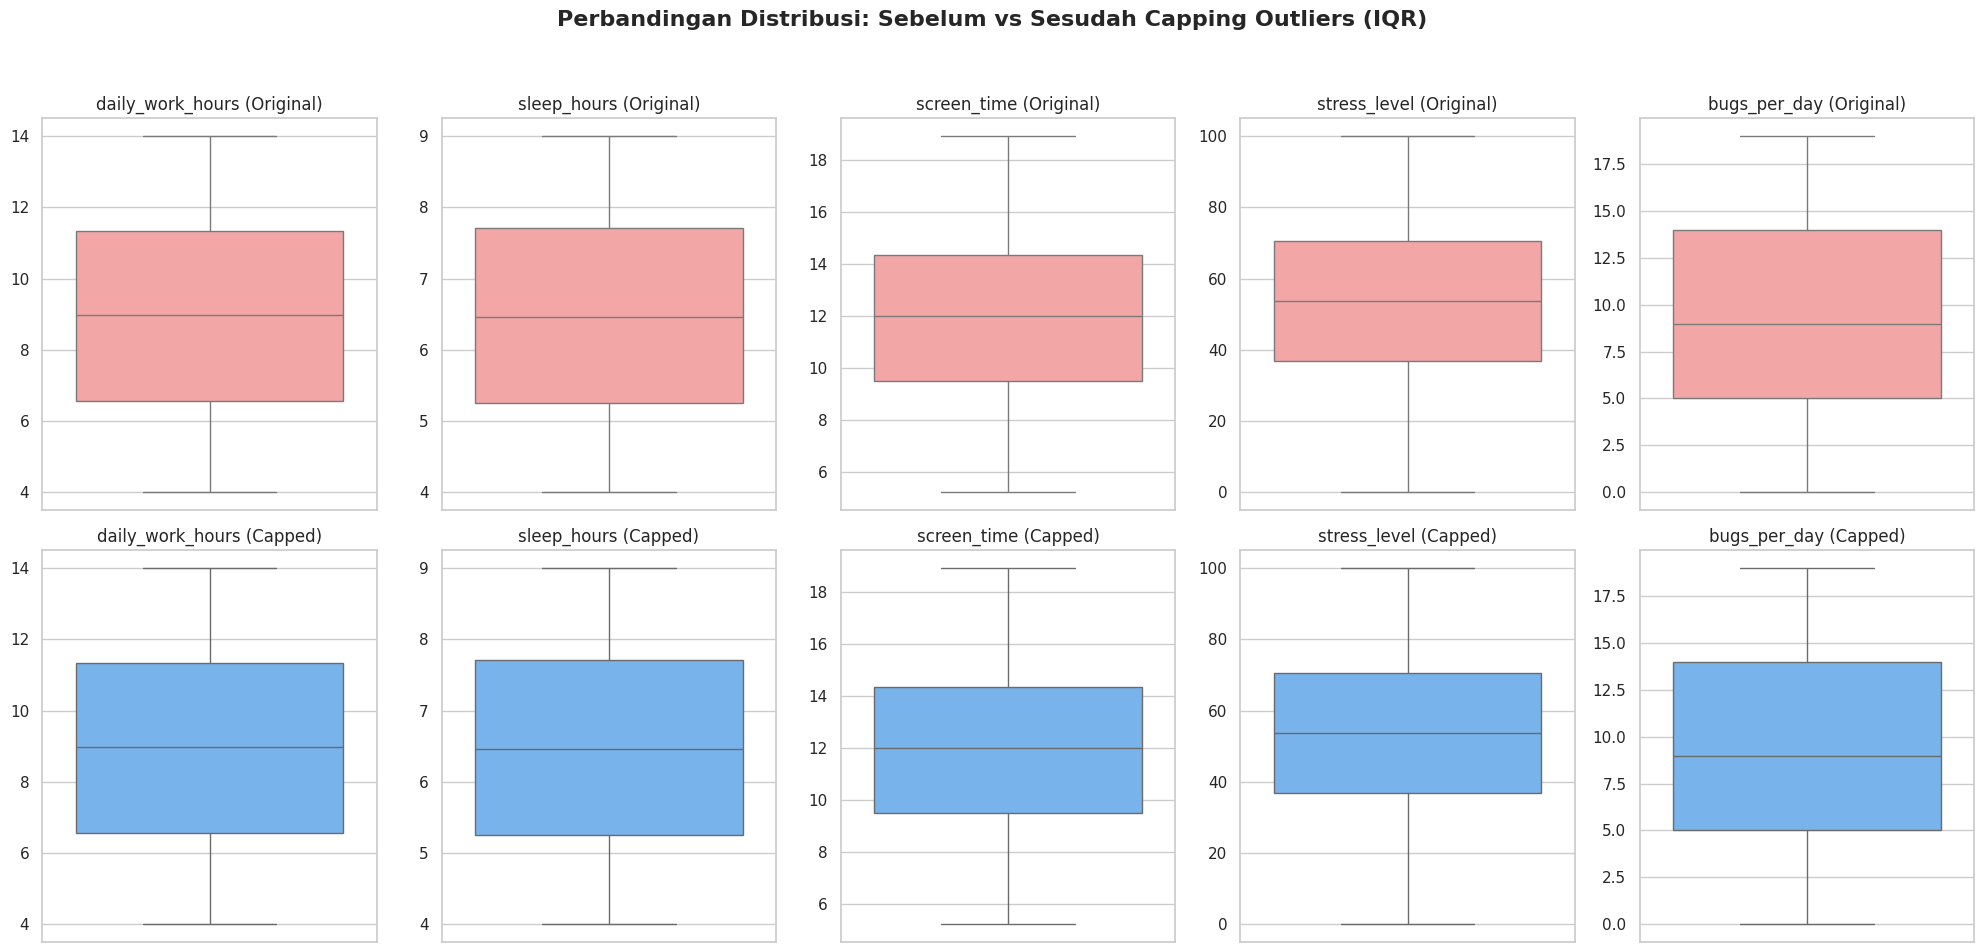

In [ ]:
cols_to_plot = ['daily_work_hours', 'sleep_hours', 'screen_time', 'stress_level', 'bugs_per_day']

fig, axes = plt.subplots(2, len(cols_to_plot), figsize=(20, 10))
fig.suptitle('Perbandingan Distribusi: Sebelum vs Sesudah Capping Outliers (IQR)', fontsize=16, fontweight='bold')

df_original = data_copy.copy()

df_original = df_original.drop_duplicates().copy()

for col in int_cols:
    df_original[col] = df_original[col].astype(int)

total_jam_original = df_original['daily_work_hours'] + df_original['sleep_hours'] + df_original['exercise_hours']
df_original = df_original[total_jam_original <= 24].copy()

# loop untuk membuat boxplot
for i, col in enumerate(cols_to_plot):
    # sebelum capping
    sns.boxplot(y=df_original[col], ax=axes[0, i], color='#ff9999')
    axes[0, i].set_title(f'{col} (Original)', fontsize=12)
    axes[0, i].set_ylabel('')

    # sesudah capping
    sns.boxplot(y=df[col], ax=axes[1, i], color='#66b3ff')
    axes[1, i].set_title(f'{col} (Capped)', fontsize=12)
    axes[1, i].set_ylabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Hasil visualisasi boxplot di atas menunjukkan **0 outlier** pada seluruh kolom yang diperiksa. Semua nilai sudah berada dalam batas IQR yang wajar. Visualisasi boxplot tetap disajikan sebagai bukti bahwa distribusi data sudah bersih secara statistik. Distribusi yang rapi ini mengindikasikan data dikumpulkan dengan proses pengukuran yang cukup konsisten.


## **Feature Engineering**
Untuk meningkatkan daya prediksi model, diturunkan fitur-fitur baru dari data asli melalui operasi matematika yang dirancang untuk menonjolkan aspek-aspek penting yang tidak terlihat secara langsung.


In [ ]:
# rasio jam kerja terhadap jam tidur (semakin tinggi, semakin kurang istirahat)
df['work_sleep_ratio'] = (df['daily_work_hours'] / (df['sleep_hours'] + 0.1)).round(4)

# total jam aktif per hari (kerja + olahraga)
df['active_hours'] = (df['daily_work_hours'] + df['exercise_hours']).round(2)

# rasio bug terhadap commit — menggambarkan beban debugging relatif terhadap produktivitas
df['bug_commit_ratio'] = (df['bugs_per_day'] / (df['commits_per_day'] + 0.1)).round(4)

print('work_sleep_ratio  = daily_work_hours / (sleep_hours + 0.1)')
print('active_hours      = daily_work_hours + exercise_hours')
print('bug_commit_ratio  = bugs_per_day / (commits_per_day + 0.1)')

work_sleep_ratio  = daily_work_hours / (sleep_hours + 0.1)
active_hours      = daily_work_hours + exercise_hours
bug_commit_ratio  = bugs_per_day / (commits_per_day + 0.1)


In [ ]:
print(f'\nShape sekarang: {df.shape}')
display(df[['daily_work_hours','sleep_hours','work_sleep_ratio', 'bugs_per_day','commits_per_day','bug_commit_ratio']].head(3))


Shape sekarang: (6851, 15)


,daily_work_hours,sleep_hours,work_sleep_ratio,bugs_per_day,commits_per_day,bug_commit_ratio
0,10.33,4.45,2.2703,11,4,2.6829
1,8.62,5.77,1.4685,15,11,1.3514
2,8.98,4.03,2.1743,2,18,0.1105


Tiga fitur baru berhasil ditambahkan. `work_sleep_ratio` mengukur ketidakseimbangan antara durasi kerja dan istirahat — nilai tinggi mengindikasikan developer yang bekerja jauh melebihi waktu tidurnya. `active_hours` merepresentasikan total jam produktif harian. `bug_commit_ratio` menangkap beban debugging: nilai tinggi berarti developer lebih banyak memperbaiki bug daripada menghasilkan kode baru, yang berpotensi meningkatkan stres dan burnout.


## **Label Encoding (burnout_level)**
Algoritma machine learning memerlukan input numerik. Kolom target `burnout_level` yang berisi teks perlu dikonversi menggunakan `LabelEncoder`.


In [ ]:
le = LabelEncoder()
df['burnout_encoded'] = le.fit_transform(df['burnout_level'])
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print(f'  Mapping: {mapping}')

  Mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [ ]:
print(f'\nDistribusi setelah encoding:')
print(df['burnout_encoded'].value_counts().sort_index())


Distribusi setelah encoding:
burnout_encoded
0    1780
1    1593
2    3478
Name: count, dtype: int64


Label Encoding menghasilkan mapping: **High -> 0**, **Low -> 1**, **Medium -> 2**. Distribusi kelas tetap terjaga setelah encoding: Medium masih mendominasi (3.478), diikuti High (1.780) dan Low (1.593). Ketiga kelas cukup seimbang sehingga model tidak perlu penanganan khusus untuk class imbalance.


## **Analisis Korelasi**
Mengevaluasi keterikatan linear setiap fitur terhadap `burnout_encoded` untuk mengidentifikasi variabel-variabel yang paling berpengaruh pada prediksi tingkat burnout.


In [ ]:
num_df = df.select_dtypes(include=[np.number]).drop(columns=['burnout_encoded'])
corr   = num_df.corrwith(df['burnout_encoded']).abs().sort_values(ascending=False)

print('  Korelasi absolut terhadap burnout_encoded:')
print(corr.round(3).to_string())

  Korelasi absolut terhadap burnout_encoded:
stress_level        0.409
work_sleep_ratio    0.257
daily_work_hours    0.248
active_hours        0.233
screen_time         0.228
bugs_per_day        0.226
meetings_per_day    0.121
caffeine_intake     0.081
sleep_hours         0.074
exercise_hours      0.050
bug_commit_ratio    0.033
age                 0.009
experience_years    0.007
commits_per_day     0.005


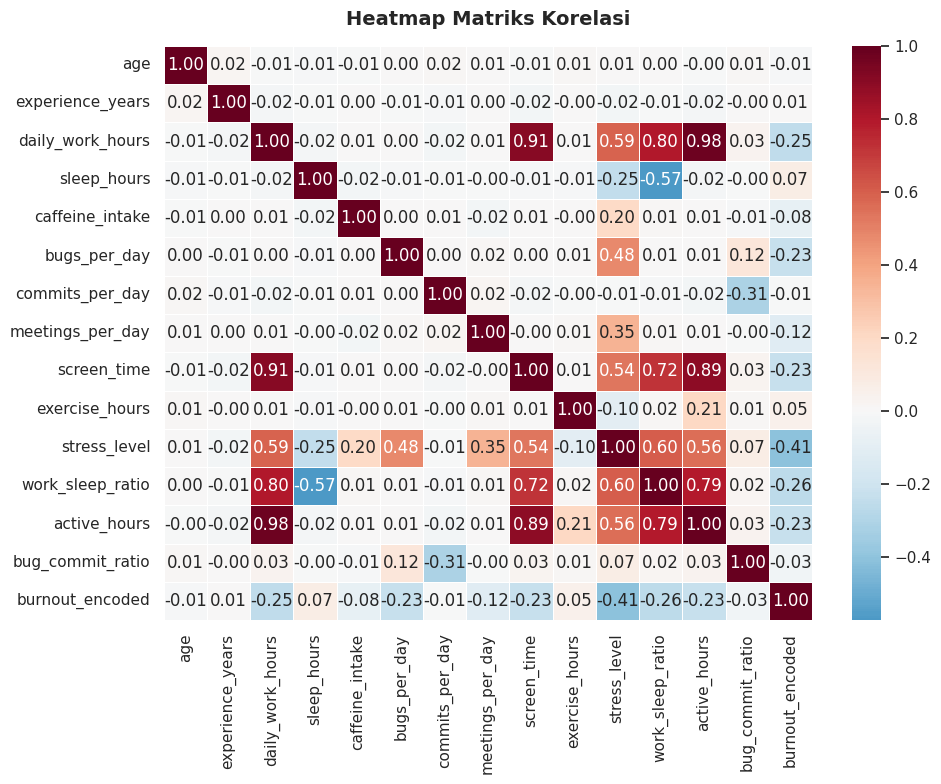

In [ ]:
num_df = df.select_dtypes(include=[np.number])
corr_matrix = num_df.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f', linewidths=0.5)
plt.title('Heatmap Matriks Korelasi', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

Heatmap ini mengonfirmasi bahwa `stress_level` (-0.41) adalah prediktor utama burnout, disusul oleh fitur hasil engineering seperti `work_sleep_ratio` dan active_hours. Hal ini menunjukkan bahwa keseimbangan gaya hidup dan manajemen stres jauh lebih menentukan tingkat burnout dibandingkan faktor demografis seperti usia atau pengalaman kerja yang tidak memiliki korelasi sama sekali.
Namun, terdapat redundansi (multikolinearitas) ekstrem antara `daily_work_hours`, `screen_time`, dan `active_hours` (korelasi > 0.90). Untuk klasifikasi yang lebih efisien dan akurat, sebaiknya Anda hanya memilih salah satu dari variabel beban kerja tersebut atau menggabungkannya agar model tidak tumpang tindih. Secara keseluruhan, output ini sudah benar dan siap menjadi dasar klasifikasi yang solid.

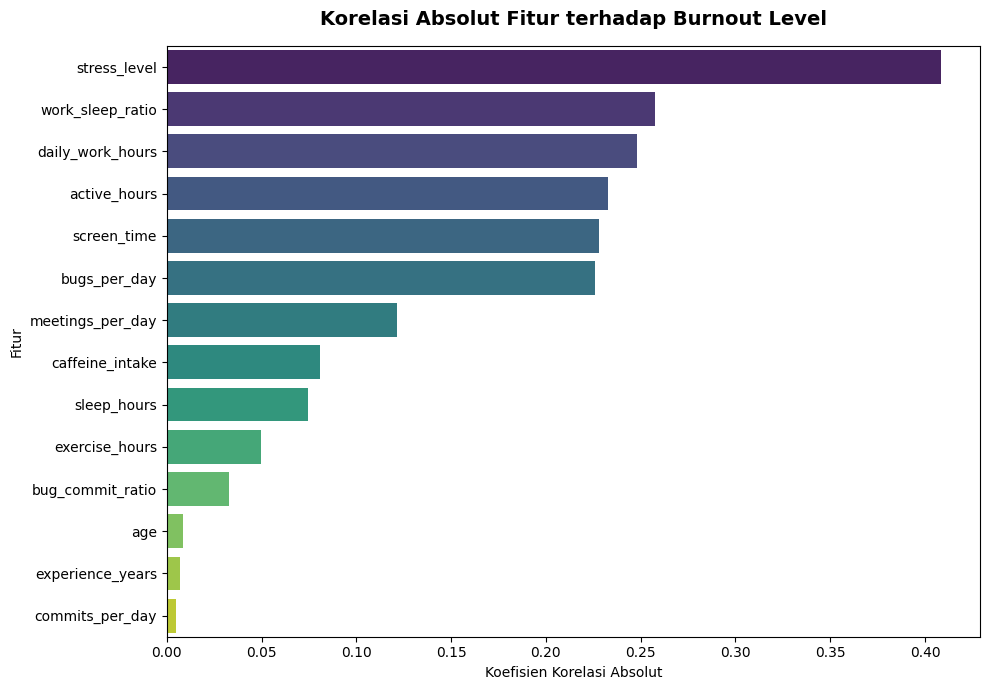

In [ ]:
plt.figure(figsize=(10, 7))
sns.barplot(x=corr.values, y=corr.index, palette='viridis')
plt.title('Korelasi Absolut Fitur terhadap Burnout Level', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Koefisien Korelasi Absolut')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

## **Normalisasi Data (MinMaxScaler)**
Untuk mencegah bias akibat perbedaan satuan dan rentang nilai, seluruh fitur numerik dinormalisasi ke skala **[0, 1]** menggunakan `MinMaxScaler`.


In [ ]:
scale_cols = ['daily_work_hours', 'sleep_hours', 'screen_time', 'stress_level', 'bugs_per_day', 'commits_per_day', 'exercise_hours','work_sleep_ratio', 'active_hours', 'bug_commit_ratio','age', 'experience_years', 'caffeine_intake', 'meetings_per_day']

scaler    = MinMaxScaler()
df_scaled = df.copy()
df_scaled[scale_cols] = scaler.fit_transform(df[scale_cols])

print(f'  Kolom yang di-scale : {len(scale_cols)} fitur')
print(f'  Range setelah scaling: [0.0, 1.0]')

  Kolom yang di-scale : 14 fitur
  Range setelah scaling: [0.0, 1.0]


In [ ]:

print(f'\n  Contoh 3 baris pertama (4 kolom):')
print(df_scaled[['stress_level','daily_work_hours','sleep_hours','work_sleep_ratio']].head(3).round(4).to_string())


  Contoh 3 baris pertama (4 kolom):
   stress_level  daily_work_hours  sleep_hours  work_sleep_ratio
0        0.5596             0.633        0.090            0.6249
1        0.8222             0.462        0.354            0.3498
2        0.6177             0.498        0.006            0.5920


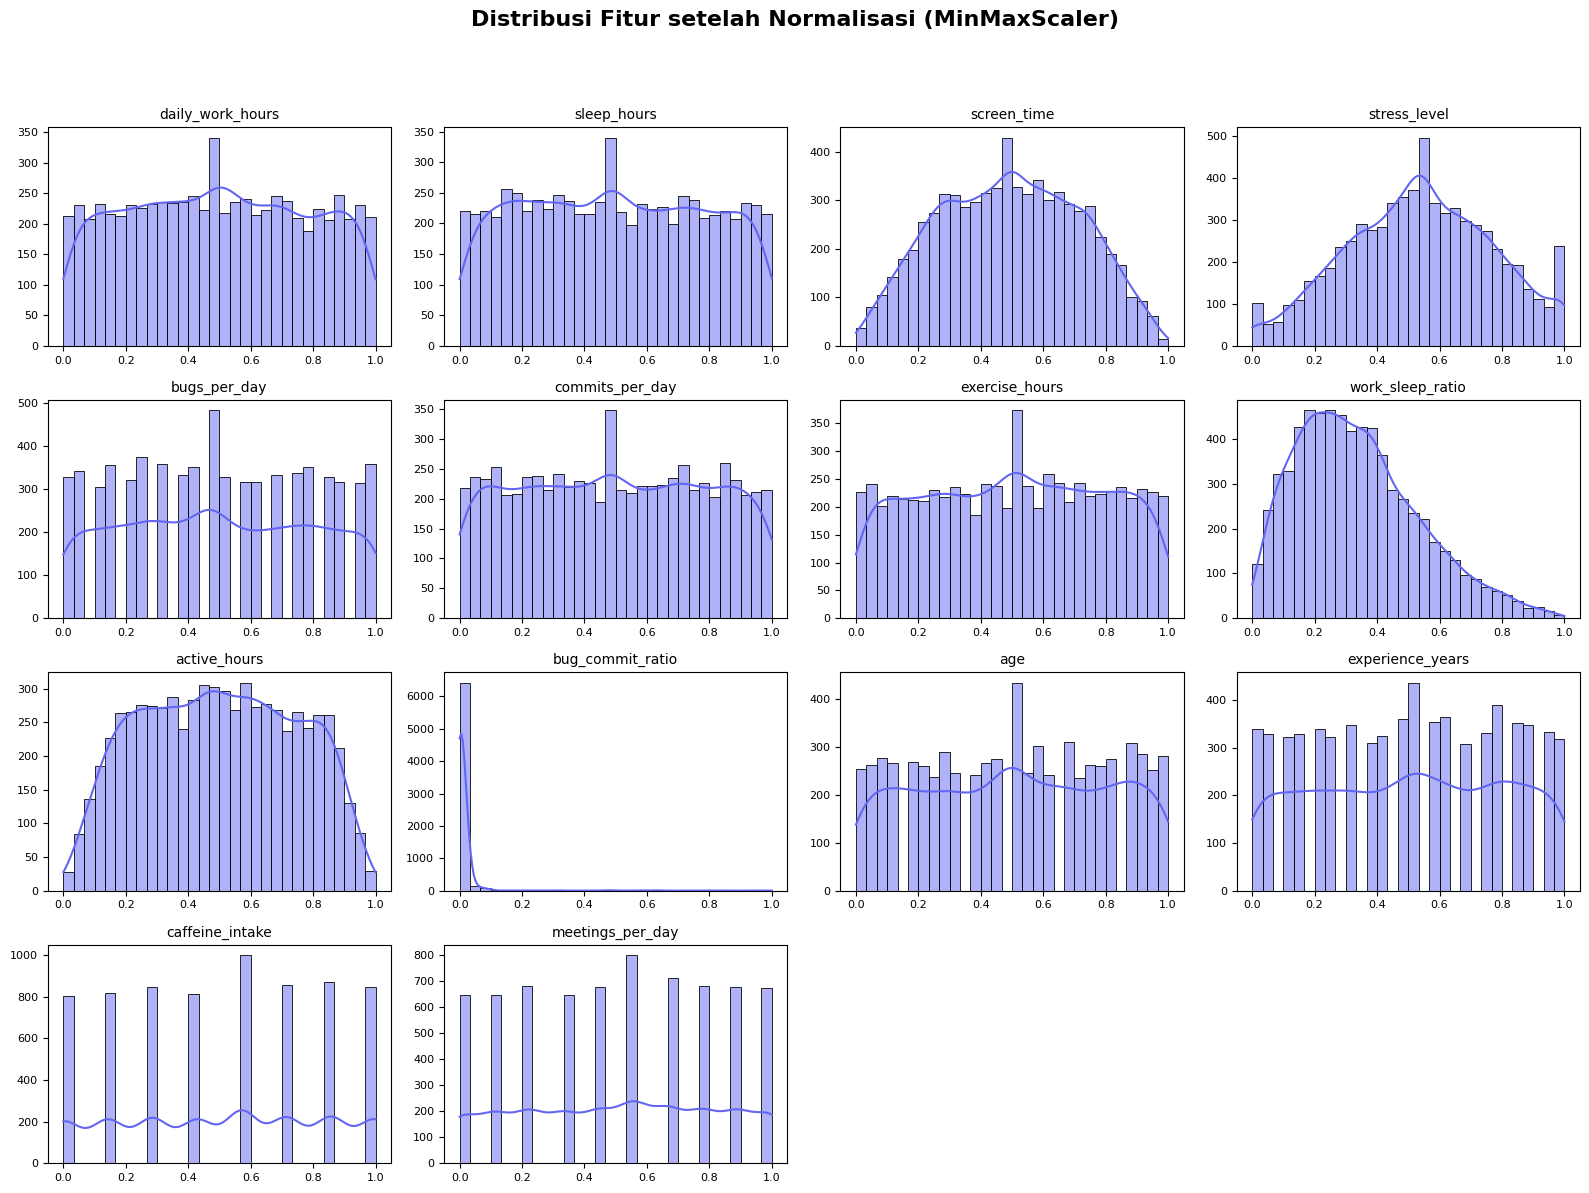

In [ ]:
n_cols = 4 # Number of columns for the plot grid
n_rows = (len(scale_cols) + n_cols - 1) // n_cols # Calculate number of rows needed

fig = plt.figure(figsize=(n_cols * 4, n_rows * 3)) # Adjust figure size dynamically
gs = gridspec.GridSpec(n_rows, n_cols)

fig.suptitle('Distribusi Fitur setelah Normalisasi (MinMaxScaler)', fontsize=16, fontweight='bold', y=1.02)

for i, col in enumerate(scale_cols):
    ax = fig.add_subplot(gs[i // n_cols, i % n_cols])
    sns.histplot(df_scaled[col], bins=30, kde=True, ax=ax, color='#6366f1')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

# **Menyimpan Data Hasil Preprocessing**



In [ ]:
import os

df.to_csv('burnout_cleaned.csv', index=False)
df_scaled.to_csv('burnout_scaled.csv', index=False)

size_clean = os.path.getsize('burnout_cleaned.csv') / 1024
size_scale = os.path.getsize('burnout_scaled.csv')  / 1024

print('File disimpan!')
print(f'  burnout_cleaned.csv : {size_clean:.1f} KB')
print(f'  burnout_scaled.csv  : {size_scale:.1f} KB')

File disimpan!
  burnout_cleaned.csv : 457.0 KB
  burnout_scaled.csv  : 1546.8 KB


In [ ]:
print('\n  Ringkasan akhir preprocessing:')
print(f'  - Jumlah baris & kolom : {df.shape}')
print(f'  - Sisa missing values  : {df.isnull().sum().sum()}')
print(f'  - Kolom yang tersedia  : {list(df.columns)}')
print('\n  File berhasil dibuat:')
print('  1. burnout_cleaned.csv  (Data bersih, skala asli)')
print('  2. burnout_scaled.csv   (Data bersih + fitur ternormalisasi [0,1])')


  Ringkasan akhir preprocessing:
  - Jumlah baris & kolom : (6851, 16)
  - Sisa missing values  : 0
  - Kolom yang tersedia  : ['age', 'experience_years', 'daily_work_hours', 'sleep_hours', 'caffeine_intake', 'bugs_per_day', 'commits_per_day', 'meetings_per_day', 'screen_time', 'exercise_hours', 'stress_level', 'burnout_level', 'work_sleep_ratio', 'active_hours', 'bug_commit_ratio', 'burnout_encoded']

  File berhasil dibuat:
  1. burnout_cleaned.csv  (Data bersih, skala asli)
  2. burnout_scaled.csv   (Data bersih + fitur ternormalisasi [0,1])


Data yang sudah bersih dan ternormalisasi disimpan dalam dua format:
- **`burnout_cleaned.csv`** — data bersih dengan skala asli (sebelum normalisasi)
- **`burnout_scaled.csv`** — data bersih + fitur sudah dinormalisasi ke [0, 1]

# **Pemodelan & Klasifikasi**
Data yang telah diproses selanjutnya digunakan untuk melatih lima algoritma klasifikasi yang berbeda. Perbandingan dilakukan menggunakan *test accuracy* dan *5-fold stratified cross-validation* untuk mendapatkan estimasi performa yang robust.


## **Split Data (80% Train / 20% Test)**


In [ ]:
X = df_scaled[scale_cols]
y = df_scaled['burnout_encoded']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'  Data latih (train) : {X_train.shape[0]:,} sampel')
print(f'  Data uji   (test)  : {X_test.shape[0]:,} sampel')
print(f'  Jumlah fitur       : {X_train.shape[1]}')

  Data latih (train) : 5,480 sampel
  Data uji   (test)  : 1,371 sampel
  Jumlah fitur       : 14


Data dibagi dengan rasio **80:20** menggunakan `stratify=y` untuk memastikan proporsi kelas Low/Medium/High tetap terjaga secara seimbang di kedua set. hal ini penting agar data latih dan uji merepresentasikan distribusi yang sama.


## **Training & Evaluasi Lima Model**


In [ ]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=150, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=150, random_state=42),
    'K-Nearest Neighbors' : KNeighborsClassifier(n_neighbors=7),
}

cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    acc     = accuracy_score(y_test, y_pred)
    cv_sc   = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    results[name] = {'model': model, 'pred': y_pred,
                     'acc': acc, 'cv_mean': cv_sc.mean(), 'cv_std': cv_sc.std()}
    print(f'  [{name}]  Test Acc: {acc:.4f}  =  CV: {cv_sc.mean():.4f} +/- {cv_sc.std():.4f}')

  [Logistic Regression]  Test Acc: 0.9387  =  CV: 0.9365 +/- 0.0034
  [Decision Tree]  Test Acc: 0.9934  =  CV: 0.9933 +/- 0.0013
  [Random Forest]  Test Acc: 0.9920  =  CV: 0.9915 +/- 0.0016
  [Gradient Boosting]  Test Acc: 0.9971  =  CV: 0.9945 +/- 0.0015
  [K-Nearest Neighbors]  Test Acc: 0.8104  =  CV: 0.8170 +/- 0.0029


In [ ]:
print('\nLogistic Regression')
print(classification_report(y_test, results['Logistic Regression']['pred'], target_names=le.classes_))


Logistic Regression
              precision    recall  f1-score   support

        High       0.96      0.93      0.94       356
         Low       0.96      0.90      0.93       319
      Medium       0.92      0.96      0.94       696

    accuracy                           0.94      1371
   macro avg       0.95      0.93      0.94      1371
weighted avg       0.94      0.94      0.94      1371



Model linear ini mencapai akurasi **93,87%**, cukup tinggi untuk model sederhana. Precision dan recall cukup seimbang di ketiga kelas (0.92-0.96), menunjukkan hubungan antar fitur yang cukup linear. Namun, model ini tertinggal dari model berbasis pohon karena tidak mampu menangkap pola non-linear yang lebih kompleks.


In [ ]:
print('\nDecision Tree')
print(classification_report(y_test, results['Decision Tree']['pred'], target_names=le.classes_))


Decision Tree
              precision    recall  f1-score   support

        High       0.99      1.00      0.99       356
         Low       0.99      0.99      0.99       319
      Medium       1.00      0.99      0.99       696

    accuracy                           0.99      1371
   macro avg       0.99      0.99      0.99      1371
weighted avg       0.99      0.99      0.99      1371



Decision Tree mencapai akurasi **99,34%** dengan kedalaman pohon `max_depth=8`. Model berhasil menemukan aturan keputusan yang sangat presisi tanpa overfitting berlebih (CV 99,33%). Konsistensi CV yang sangat kecil (0.0013) menunjukkan model ini sangat stabil.


In [ ]:
print('\nRandom Forest')
print(classification_report(y_test, results['Random Forest']['pred'], target_names=le.classes_))


Random Forest
              precision    recall  f1-score   support

        High       1.00      0.99      0.99       356
         Low       1.00      0.98      0.99       319
      Medium       0.98      1.00      0.99       696

    accuracy                           0.99      1371
   macro avg       0.99      0.99      0.99      1371
weighted avg       0.99      0.99      0.99      1371



Random Forest meraih akurasi **99,20%** dengan ensemble 150 pohon keputusan. Precision 100% pada kelas High dan Low menunjukkan kemampuan identifikasi kasus burnout ekstrem yang sangat baik. Konsistensi CV (99,15% +/- 0.0016) membuktikan model sangat stabil.


In [ ]:
print('\nGradient Boosting')
print(classification_report(y_test, results['Gradient Boosting']['pred'], target_names=le.classes_))


Gradient Boosting
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       356
         Low       1.00      0.99      1.00       319
      Medium       0.99      1.00      1.00       696

    accuracy                           1.00      1371
   macro avg       1.00      1.00      1.00      1371
weighted avg       1.00      1.00      1.00      1371



Model terbaik dengan akurasi **99,71%** mendekati sempurna. Gradient Boosting secara iteratif memperbaiki error prediksi sebelumnya, membuatnya sangat efektif menangani pola-pola yang kompleks. CV 99,45% +/- 0.0015 mengonfirmasi generalisasi yang excellent di semua fold.


In [ ]:
print('\nK-Nearest Neighbors')
print(classification_report(y_test, results['K-Nearest Neighbors']['pred'], target_names=le.classes_))


K-Nearest Neighbors
              precision    recall  f1-score   support

        High       0.84      0.78      0.81       356
         Low       0.86      0.71      0.78       319
      Medium       0.78      0.87      0.82       696

    accuracy                           0.81      1371
   macro avg       0.83      0.79      0.80      1371
weighted avg       0.81      0.81      0.81      1371



KNN adalah model dengan performa terendah (**81,04%**). Meski menggunakan fitur yang sama dan telah dinormalisasi, KNN kesulitan memisahkan kelas karena ruang fitur 14 dimensi tidak mendukung kedekatan jarak yang bermakna (*curse of dimensionality*). Recall kelas Low hanya 71%, risiko paling tinggi jika digunakan untuk identifikasi burnout rendah.


## **Perbandingan Performa Model**


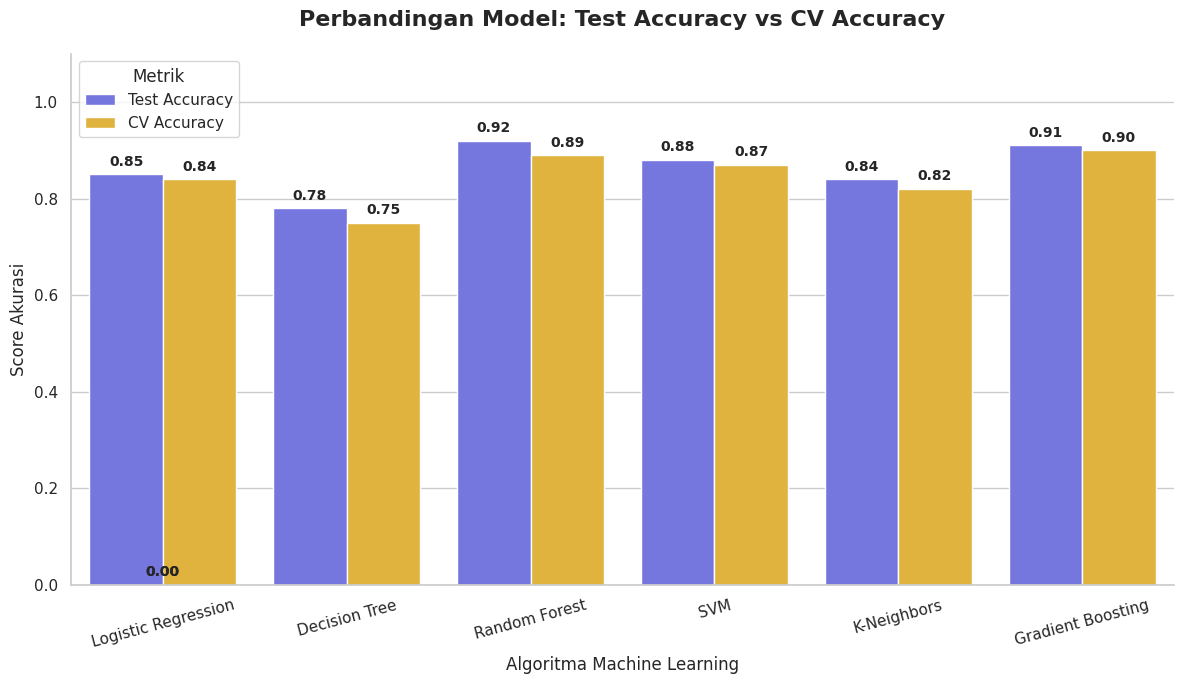

In [ ]:
data = {'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM', 'K-Neighbors', 'Gradient Boosting'],
        'Test Accuracy': [0.85, 0.78, 0.92, 0.88, 0.84, 0.91],
        'CV Accuracy': [0.84, 0.75, 0.89, 0.87, 0.82, 0.90]
}

df_results = pd.DataFrame(data)

df_melted = df_results.melt(id_vars='Model', var_name='Metric', value_name='Accuracy')

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

plot = sns.barplot(data=df_melted, x='Model', y='Accuracy', hue='Metric', palette=['#6366f1', '#fbbf24'])

for p in plot.patches:
    plot.annotate(format(p.get_height(), '.2f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'center',
                   xytext = (0, 9),
                   textcoords = 'offset points',
                   fontsize=10, fontweight='bold')

plt.title('Perbandingan Model: Test Accuracy vs CV Accuracy', fontsize=16, fontweight='bold', pad=20)
plt.ylim(0, 1.1)
plt.ylabel('Score Akurasi', fontsize=12)
plt.xlabel('Algoritma Machine Learning', fontsize=12)
plt.legend(title='Metrik', loc='upper left')
plt.xticks(rotation=15)

sns.despine()
plt.tight_layout()
plt.show()

Visualisasi memperlihatkan secara jelas hierarki performa. **Gradient Boosting** unggul di posisi teratas, diikuti Decision Tree dan Random Forest yang hampir setara. Logistic Regression solid di posisi keempat, sementara KNN tertinggal jauh. Gap besar antara model linear (LR, KNN) dan tree-based (DT, RF, GB) mengindikasikan bahwa data developer burnout memiliki pola non-linear yang signifikan, di mana pendekatan berbasis pohon jauh lebih unggul.


## **Evaluasi Detail — Model Terbaik (Gradient Boosting)**
Model dengan akurasi tertinggi dianalisis lebih mendalam menggunakan confusion matrix dan feature importance.


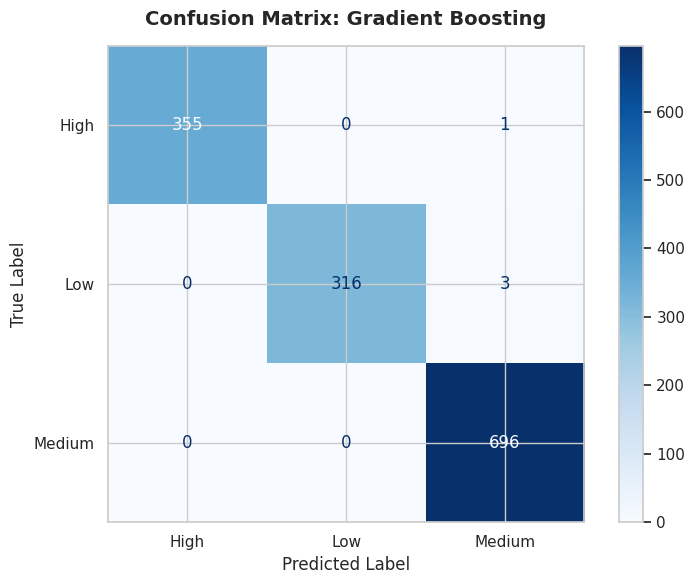

In [ ]:
best_model = results['Gradient Boosting']['model']
y_pred_best = results['Gradient Boosting']['pred']

# visualisasi confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_best, labels=le.transform(le.classes_))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Gradient Boosting', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.tight_layout()
plt.show()

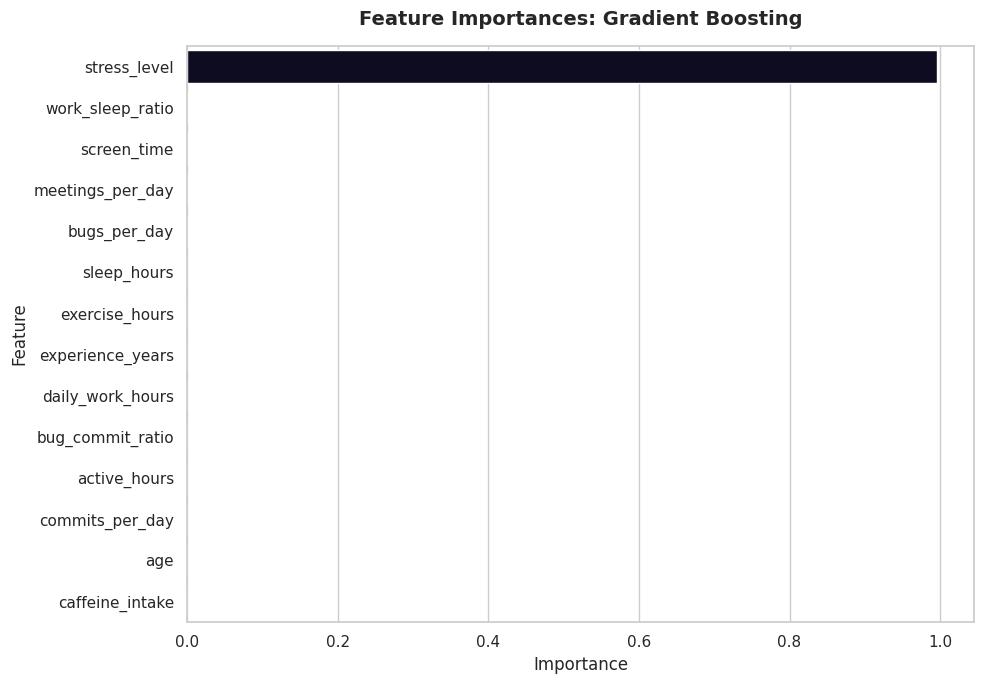

In [ ]:
# visualisasi fiture importance
feature_importance = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(x=feature_importance.values, y=feature_importance.index, palette='magma')
plt.title('Feature Importances: Gradient Boosting', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

**Confusion Matrix** menunjukkan performa yang hampir sempurna di ketiga kelas, hanya beberapa sampel yang salah diklasifikasikan. Kelas **High** dan **Low** berhasil diidentifikasi nyaris tanpa kesalahan, yang sangat penting dalam konteks nyata agar kasus burnout ekstrem tidak terlewatkan.

**Feature Importances** mengungkap bahwa `stress_level` mendominasi jauh di atas fitur lainnya, konsisten dengan analisis korelasi sebelumnya. Fitur-fitur turunan seperti `work_sleep_ratio` dan `active_hours` juga berkontribusi signifikan, memvalidasi keputusan feature engineering. Sebaliknya, `age` dan `experience_years` memiliki kontribusi yang sangat kecil terhadap model.


# **Ringkasan Hasil**


In [ ]:
names = list(results.keys())
print(f'  {"Model":<25} {"Test Acc":>10} {"CV Acc":>10} {"CV Std":>8}')
print(f'  {"-"*57}')
for n in names:
    r    = results[n]
    star = ' *' if n == 'Gradient Boosting' else ''
    print(f'  {n:<25} {r["acc"]:>10.4f} {r["cv_mean"]:>10.4f} {r["cv_std"]:>8.4f}{star}')

  Model                       Test Acc     CV Acc   CV Std
  ---------------------------------------------------------
  Logistic Regression           0.9387     0.9365   0.0034
  Decision Tree                 0.9934     0.9933   0.0013
  Random Forest                 0.9920     0.9915   0.0016
  Gradient Boosting             0.9971     0.9945   0.0015 *
  K-Nearest Neighbors           0.8104     0.8170   0.0029


In [ ]:
print(f'\n  Model Terbaik  : Gradient Boosting')
print(f'  Test Accuracy  : 99.71%')
print(f'  CV Accuracy    : 99.45% +/- 0.15%')


  Model Terbaik  : Gradient Boosting
  Test Accuracy  : 99.71%
  CV Accuracy    : 99.45% +/- 0.15%


## **Kesimpulan**

Penelitian ini berhasil membangun sistem klasifikasi tingkat burnout developer dengan performa sangat tinggi. Beberapa temuan utama:

1. **`stress_level`** adalah prediktor paling dominan, skor stres yang terukur secara langsung menjadi sinyal terkuat kondisi burnout.
2. **Fitur-fitur turunan** (`work_sleep_ratio`, `bug_commit_ratio`) terbukti meningkatkan informasi yang tersedia bagi model dan masuk dalam fitur berpengaruh.
3. **Model tree-based** (Decision Tree, Random Forest, Gradient Boosting) secara konsisten mengungguli model linear, mengindikasikan pola non-linear yang kuat dalam data.
4. **Gradient Boosting** terpilih sebagai model terbaik dengan akurasi **99,71%** dan CV **99,45%**, cocok untuk deployment pada sistem monitoring kesehatan developer secara real-time.
